In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras.models import Sequential
from keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Load the realistic dataset
data = pd.read_csv('/content/hajj_realistic_data.csv')

# Encoding categorical variables
label_encoders = {}
categorical_columns = ['Gender', 'Health Condition', 'Population Density', 'Nearby Medical Facilities', 'Route']

risk_level_encoder = LabelEncoder()
data['Risk Level'] = risk_level_encoder.fit_transform(data['Risk Level'])
for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Defining features (X) and target (y)
X = data.drop(columns=['Risk Level'])
y = LabelEncoder().fit_transform(data['Risk Level'])


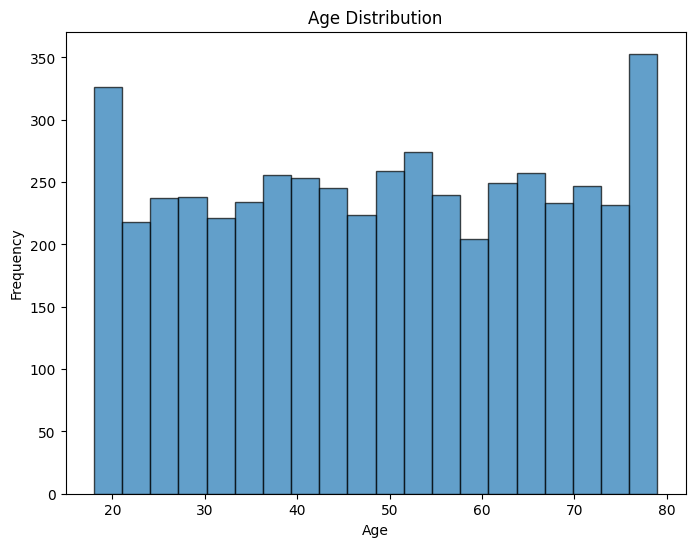

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['Age'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

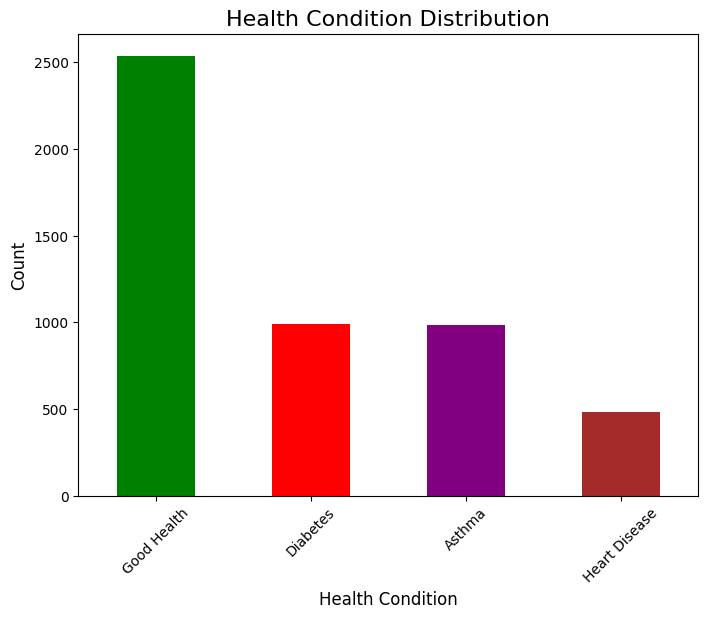

In [ ]:
# فك الترميز لعمود "Health Condition" لإعادة النصوص الأصلية
data['Health Condition'] = label_encoders['Health Condition'].inverse_transform(data['Health Condition'])

# رسم توزيع Health Condition
plt.figure(figsize=(8, 6))
data['Health Condition'].value_counts().plot(kind='bar', color=['green', 'red', 'purple', 'brown'])
plt.title('Health Condition Distribution', fontsize=16)
plt.xlabel('Health Condition', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)  # تدوير النصوص لتناسب العرض
plt.show()

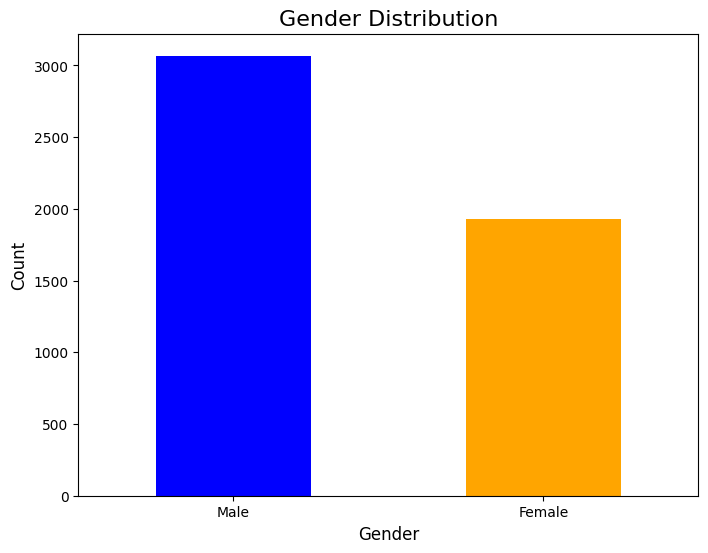

In [ ]:
# فك الترميز لعمود "Gender" لإعادة النصوص الأصلية
data['Gender'] = label_encoders['Gender'].inverse_transform(data['Gender'])
# رسم توزيع Gender
plt.figure(figsize=(8, 6))
data['Gender'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Gender Distribution', fontsize=16)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)  # عرض النصوص بشكل أفقي
plt.show()

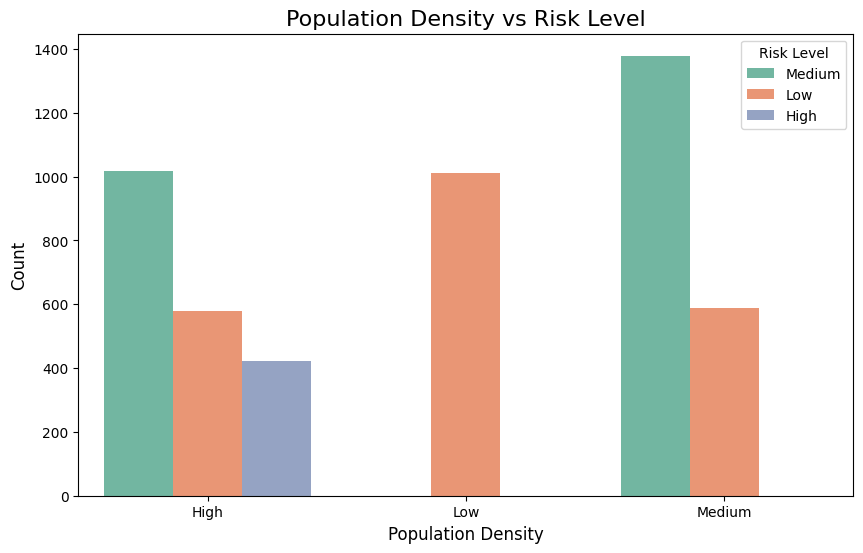

In [ ]:
# تعريف خريطة Population Density
population_density_map = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

# تعريف خريطة Risk Level
risk_level_map = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

# استبدال الأرقام بالنصوص
data['Population Density'] = data['Population Density'].map(population_density_map)
data['Risk Level'] = data['Risk Level'].map(risk_level_map)

# رسم Population Density vs Risk Level
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Population Density', hue='Risk Level', palette='Set2')
plt.title('Population Density vs Risk Level', fontsize=16)
plt.xlabel('Population Density', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Risk Level', fontsize=10)
plt.xticks(rotation=0)  # النصوص تظهر بشكل أفقي
plt.show()

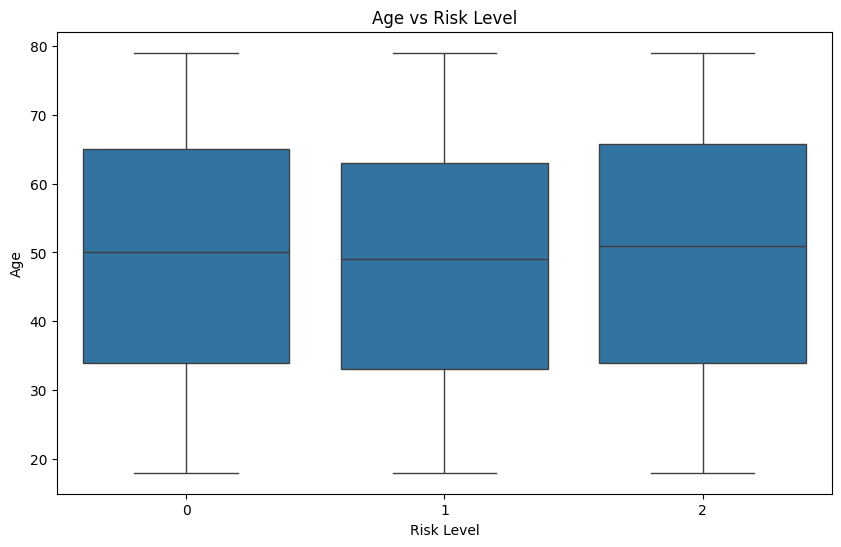

In [ ]:
# Age vs Risk Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Risk Level', y='Age')
plt.title('Age vs Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Age')
plt.show()

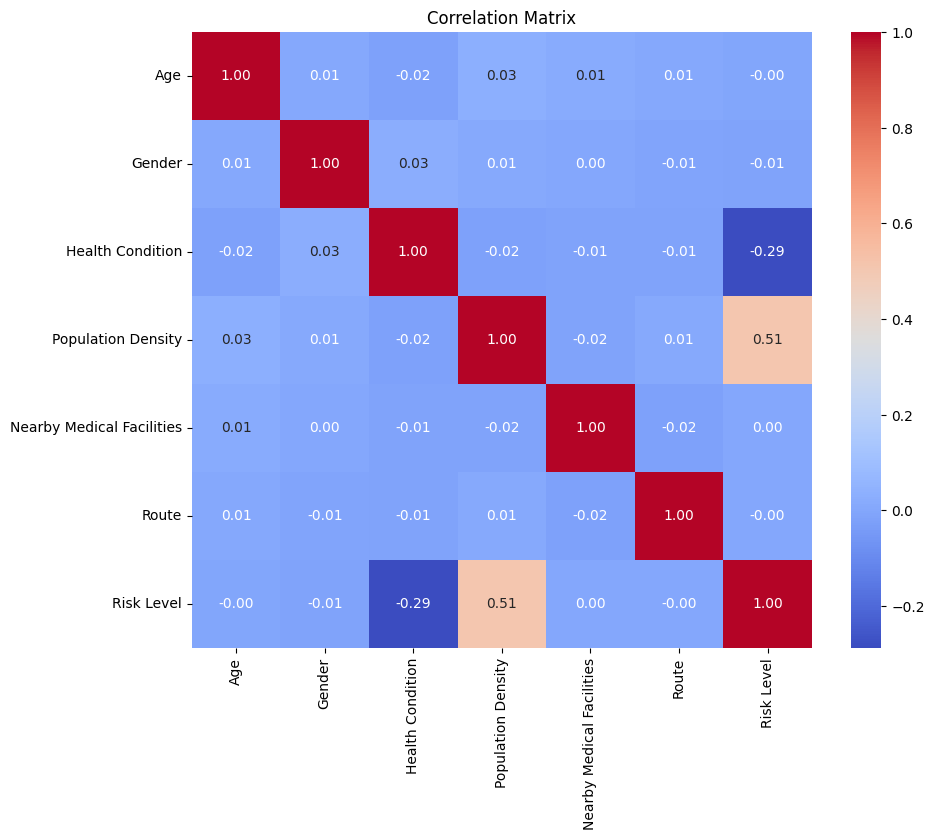

In [ ]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


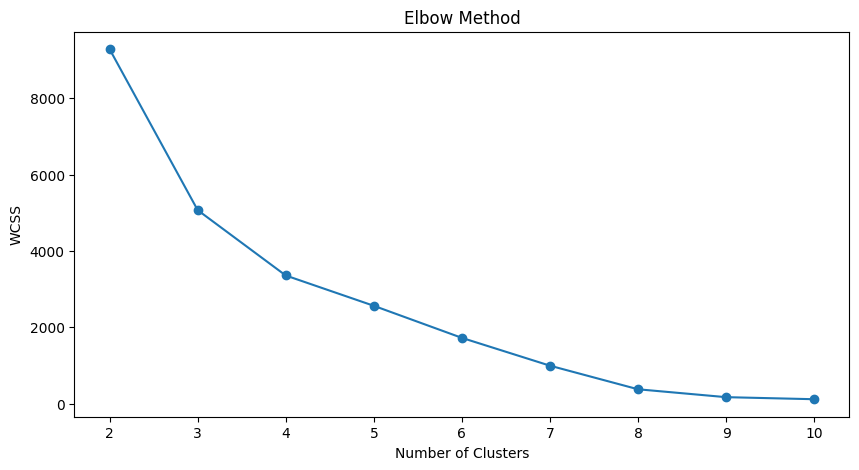

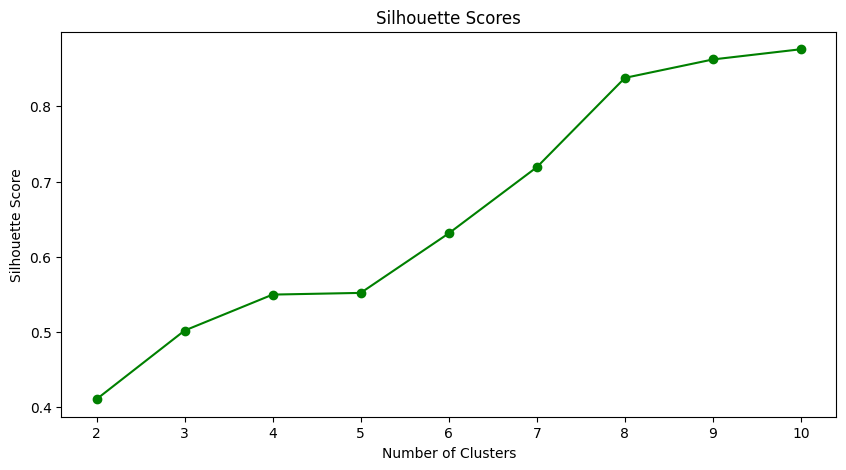

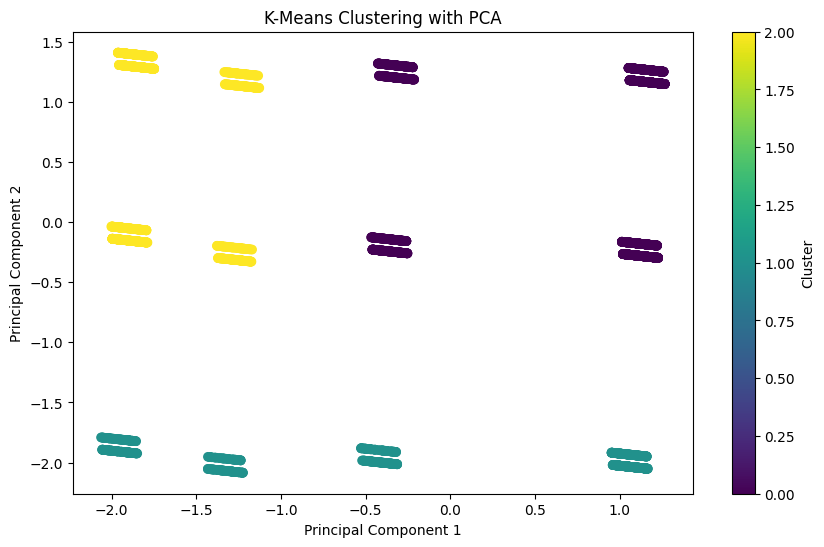

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Select additional features for clustering
features = ['Age', 'Gender', 'Population Density', 'Health Condition']
X = data[features]

# Convert categorical features to numerical
X = pd.get_dummies(X, columns=['Gender', 'Health Condition', 'Population Density'], drop_first=True)

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce dimensions
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# Determine optimal number of clusters using the Elbow method
wcss = []
silhouette_scores = []

for i in range(2, 11):  # Start from 2 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, kmeans.labels_))

# Plot the Elbow method
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Plot Silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.title('Silhouette Scores')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Choose the optimal number of clusters based on the Elbow method and Silhouette score
k = 3

# Perform K-Means clustering
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_pca)

# Assign cluster labels to the DataFrame
data['Cluster'] = kmeans.labels_

# Visualize the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['Cluster'], cmap='viridis')
plt.title('K-Means Clustering with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================
# Machine Learning Model
# ========================
# Training a Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       436
           1       1.00      1.00      1.00       480
           2       1.00      1.00      1.00        84

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Random Forest Model Accuracy: 100.00%


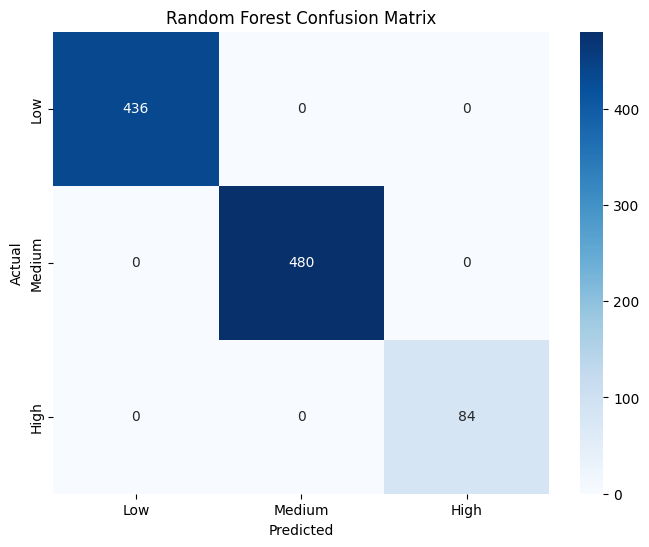

In [ ]:
# Predicting and evaluating the Random Forest model

rf_y_pred = rf_model.predict(X_test_scaled)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

# Calculate and display accuracy for the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
print(f"Random Forest Model Accuracy: {rf_accuracy * 100:.2f}%")

# Visualizing the confusion matrix for Random Forest
rf_conf_matrix = confusion_matrix(y_test, rf_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(rf_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model = Sequential()
model.add(Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))  # 3 classes: Low, Medium, High

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=50, batch_size=32, verbose=1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4562 - loss: 1.0579 - val_accuracy: 0.6390 - val_loss: 0.7407
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6009 - loss: 0.7945 - val_accuracy: 0.7380 - val_loss: 0.6223
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6428 - loss: 0.6948 - val_accuracy: 0.7640 - val_loss: 0.5422
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6761 - loss: 0.6295 - val_accuracy: 0.7680 - val_loss: 0.4870
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7097 - loss: 0.5801 - val_accuracy: 0.7770 - val_loss: 0.4417
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7537 - loss: 0.5153 - val_accuracy: 0.8010 - val_loss: 0.4008
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7619 - loss: 0.4970 - val_accuracy: 0.8490 - val_loss: 0.3521
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8167 - loss: 0.4345 - val_accuracy: 0.

Deep Learning Model Accuracy: 100.00%


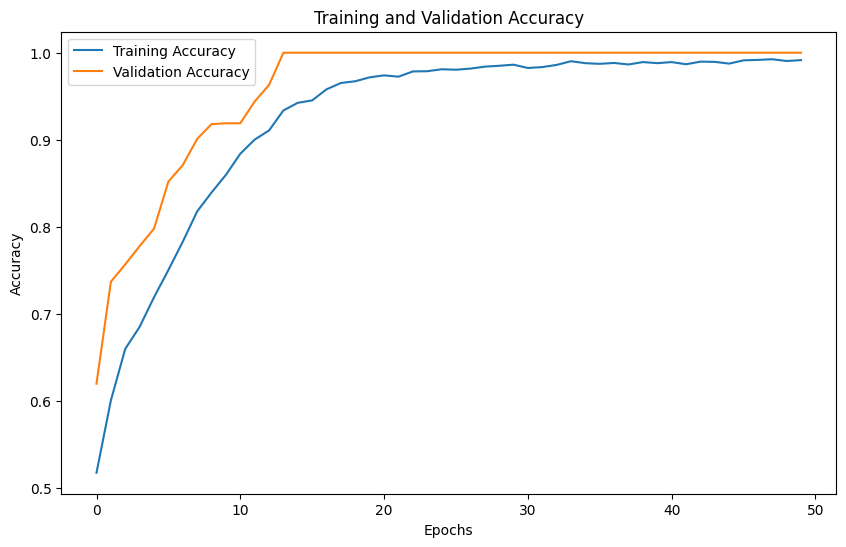

In [ ]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Deep Learning Model Accuracy: {accuracy * 100:.2f}%")

# Plot training and validation accuracy
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

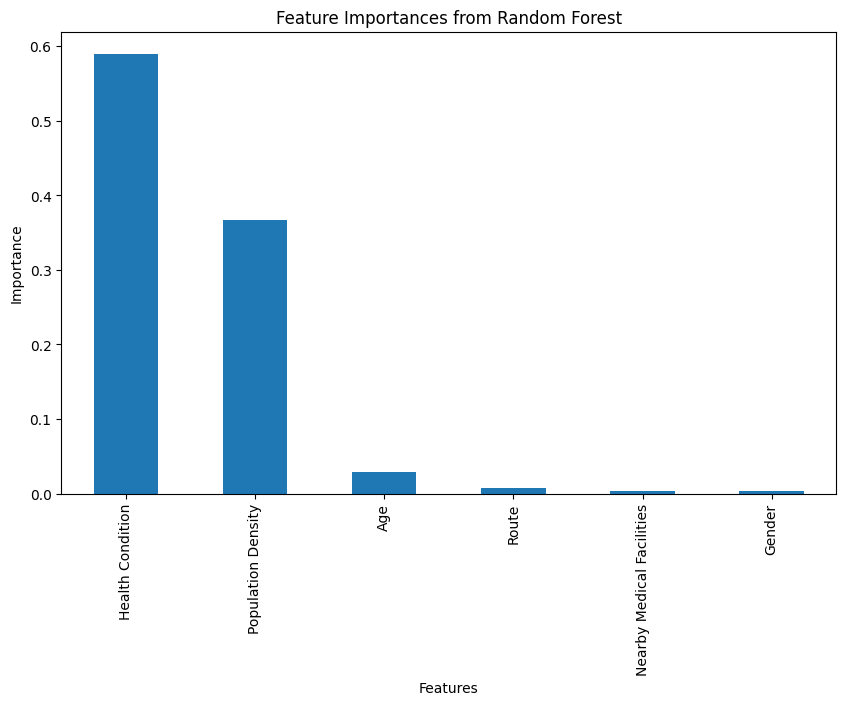

In [ ]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title('Feature Importances from Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [ ]:
test_data = pd.read_csv('/content/test_data.csv')




data['Risk Level'] = risk_level_encoder.fit_transform(data['Risk Level'])
# Handle unseen labels in the new test data
for col in categorical_columns:
    if col in test_data.columns:
        test_data[col] = test_data[col].apply(lambda x: label_encoders[col].transform([x])[0] if x in label_encoders[col].classes_ else -1)

# Ensure the same scaling is applied
test_data_scaled = scaler.transform(test_data)

# Predict using Random Forest
rf_test_predictions = rf_model.predict(test_data_scaled)
rf_test_predictions_named = risk_level_encoder.inverse_transform(rf_test_predictions)
print("Random Forest Predictions:")
print(rf_test_predictions_named)


dl_test_predictions = model.predict(test_data_scaled)
dl_test_predictions_classes = np.argmax(dl_test_predictions, axis=1)
dl_test_predictions_named = risk_level_encoder.inverse_transform(dl_test_predictions_classes)
print("Deep Learning Predictions:")
print(dl_test_predictions_named)


Random Forest Predictions:
[0 1 1 0 2 0 0 1 1 2 0 1 0 0 1 0 0 1 1 2 1]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Deep Learning Predictions:
[0 1 1 0 2 0 1 1 1 2 0 1 0 0 1 0 0 1 1 2 1]


# ========================
# Hajj Risk Route Dashboard
# ========================


In [ ]:
!pip install dash pandas plotly jupyter-dash
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.4 MB/s eta 0:00:00
  Attempting uninstall: Werkzeug
    Found existing installation: Werkzeug 3.1.3
    Uninstalling Werkzeug-3.1.3:
      Successfully uninstalled Werkzeug-3.1.3
  Attempting uninstall: Flask
    Found existing installation: Flask 3.1.0
    Uninstalling Flask-3.1.0:
      Successfully uninstalled Flask-3.1.0


In [ ]:
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import folium
from folium.plugins import MarkerCluster
import random

# Load data from the local file
data = pd.read_csv('hajj_realistic_data.csv')

# Sample 100 rows only
data_sample = data.sample(n=100, random_state=42)

# Coordinates for routes leading to Arafat
routes_coordinates = {
    "Route 1": [21.4000, 39.8500],
    "Route 2": [21.3950, 39.8600],
    "Route 3": [21.3900, 39.8700],
    "Route 4": [21.3850, 39.8800]
}

# Initialize the Dash app
app = dash.Dash(__name__)

# Create a dropdown menu for pedestrian routes
dropdown_options = [{"label": route, "value": route} for route in routes_coordinates.keys()]

# Layout of the app
app.layout = html.Div([
    html.H1("Hajj Risk Route Dashboard - Pedestrian Routes", style={'textAlign': 'center'}),
    dcc.Dropdown(
        id="route-dropdown",
        options=dropdown_options,
        value="Route 1",
        placeholder="Select a Route",
        style={'margin-bottom': '20px'}
    ),
    html.Iframe(id="map", width="100%", height="600", style={'border': 'none'})
])

# Callback to update the map based on the selected route
@app.callback(
    Output("map", "srcDoc"),
    Input("route-dropdown", "value")
)
def update_map(selected_route):
    # Filter data for the selected route
    filtered_data = data_sample[data_sample["Route"] == selected_route]

    # Get the central coordinates for the selected route
    route_coords = routes_coordinates[selected_route]

    # Create a folium map centered around the selected route
    folium_map = folium.Map(location=route_coords, zoom_start=14)
    marker_cluster = MarkerCluster().add_to(folium_map)

    # Add markers for danger cases with slight random variation
    for _, row in filtered_data.iterrows():
        lat_offset = random.uniform(-0.002, 0.002)  # Small random offset in latitude
        lon_offset = random.uniform(-0.002, 0.002)  # Small random offset in longitude
        folium.Marker(
            location=[route_coords[0] + lat_offset, route_coords[1] + lon_offset],
            popup=f"Age: {row['Age']}, Risk: {row['Risk Level']}, Health: {row['Health Condition']}",
            icon=folium.Icon(color="red" if row["Risk Level"] == "High" else "orange")
        ).add_to(marker_cluster)

    # Return the HTML representation of the folium map
    return folium_map._repr_html_()

# Run the app in a separate page
if __name__ == "__main__":
    app.run_server(debug=True)


<IPython.core.display.Javascript object>